In [37]:
import os
import json
import pandas as pd
import numpy as np
import glob

# Define the root directory
root_dir = 'results_2511'

# List to store the extracted data
all_records = []

# Walk through the directory structure
# We assume structure: results_2511/strategy/language/model_folder/json_file
for root, dirs, files in os.walk(root_dir):
    print("Processing directory:", root)
    for file in files:
        if file.endswith('.json'):

            file_path = os.path.join(root, file)
            
            if "zero_shot+specific" in root or "reflexion" in root:
                continue  # Skip specific model runs if needed
            
            try:
                # Read JSON content
                with open(file_path, 'r') as f:
                    content = json.load(f)
                
                # Extract sections
                metadata = content.get('metadata', {})
                data_list = content.get('data', [])
                
                # Skip if data list is empty
                if not data_list:
                    continue
                    
                # --- 1. Extract Info from Folder Structure (as requested) ---
                # Get path parts to identify language and model string
                path_parts = os.path.normpath(file_path).split(os.sep)
                
                # Assuming depth: .../language/model_folder/file.json
                # Python negative indexing is safer:
                language_from_folder = path_parts[-3] if len(path_parts) >= 3 else "unknown"
                model_folder_name = path_parts[-2] if len(path_parts) >= 2 else "unknown"
                
                # Parse "code_llm" and "answer_llm" from folder name
                # Format: "generator+verifier__v1"
                if '+' in model_folder_name:
                    parts = model_folder_name.split('__')[0].split('+')
                    folder_code_llm = parts[0]
                    folder_answer_llm = parts[1] if len(parts) > 1 else "unknown"
                else:
                    folder_code_llm = model_folder_name
                    folder_answer_llm = "unknown"

                # --- 2. Process Ground Truth (GT) ---
                # Logic: NaN -> Yes, "No" -> No
                raw_gt = metadata.get('answer')
                
                gt_normalized = "Unknown"
                
                # Handle Float NaN, None, or String "NaN"
                is_nan = False
                if raw_gt is None:
                    is_nan = True
                elif isinstance(raw_gt, float) and np.isnan(raw_gt):
                    is_nan = True
                elif str(raw_gt).strip() == "NaN":
                    is_nan = True
                    
                if is_nan:
                    gt_normalized = "Yes"
                elif str(raw_gt).lower().strip() == "no":
                    gt_normalized = "No"
                else:
                    # Keep original if it's something unexpected (e.g. "Yes")
                    gt_normalized = str(raw_gt)

                # --- 3. Process Model Prediction ---
                # Taking the first iteration from 'data' list
                model_data = data_list[0]
                prediction_code = model_data.get('answer')
                
                # Map codes to meanings for readability (optional, but helpful)
                pred_meaning_map = {
                    "A": "Yes",
                    "B": "No",
                    "C1": "Empty Collection",
                    "C2": "No Valid Pixels",
                    "C3": "Calculation Failure",
                    "D": "Execution Error"
                }
                pred_meaning = pred_meaning_map.get(prediction_code, "Unknown Code")

                # --- 4. Build Record ---
                record = {
                    # Identifiers
                    "unique_id": metadata.get('unique_id'),
                    "filename": file,
                    
                    # Context
                    "language": metadata.get('language') or language_from_folder,
                    "strategy": metadata.get('strategy'),
                    
                    # LLM Info (Prefer metadata, fallback to folder parsing if needed)
                    "code_llm": metadata.get('code_llm', folder_code_llm),
                    "answer_llm": metadata.get('answer_llm', folder_answer_llm),
                    "folder_name": model_folder_name, # Kept for verification
                    
                    # Ground Truth
                    "gt_raw": raw_gt,
                    "gt_answer": gt_normalized,
                    
                    # Prediction
                    "pred_code": prediction_code,
                    "pred_meaning": pred_meaning,
                    
                    # Execution details (Optional but useful for analysis)
                    "exec_returncode": model_data.get('exec_returncode'),
                    "question": metadata.get('question')
                }
                
                all_records.append(record)
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Create DataFrame
df = pd.DataFrame(all_records)

# Sort for cleaner viewing (e.g., by LLM and ID)
if not df.empty:
    df = df.sort_values(by=['code_llm', 'unique_id'])

# Display info
print(f"Total files processed: {len(df)}")
print("Columns available:", df.columns.tolist())
print()

# Show the first few rows
df.head()


Processing directory: results_2511
Processing directory: results_2511/reflexion_1
Processing directory: results_2511/reflexion_1/python
Processing directory: results_2511/reflexion_1/python/gemini-2.5-flash+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/gpt-5+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific
Processing directory: results_2511/zero_shot+specific/python
Processing directory: results_2511/zero_shot+specific/python/gemini-2.5-flash+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot
Processing directory: results_2511

,unique_id,filename,language,strategy,code_llm,answer_llm,folder_name,gt_raw,gt_answer,pred_code,pred_meaning,exec_returncode,question
1346,1,memory_1.json,python,zero_shot,claude-haiku-4-5-20251001,gemini-2.5-flash,claude-haiku-4-5-20251001+gemini-2.5-flash__v1,NaN,Yes,D,Execution Error,1,Does Australia show higher carbon monoxide con...
4212,1,memory_1.json,javascript,zero_shot,claude-haiku-4-5-20251001,gemini-2.5-flash,claude-haiku-4-5-20251001+gemini-2.5-flash__v1,NaN,Yes,D,Execution Error,1,Does Australia show higher carbon monoxide con...
1525,2,memory_2.json,python,zero_shot,claude-haiku-4-5-20251001,gemini-2.5-flash,claude-haiku-4-5-20251001+gemini-2.5-flash__v1,NaN,Yes,B,No,0,Does the valley fog coverage in the Upper Arro...
4276,2,memory_2.json,javascript,zero_shot,claude-haiku-4-5-20251001,gemini-2.5-flash,claude-haiku-4-5-20251001+gemini-2.5-flash__v1,NaN,Yes,D,Execution Error,1,Does the valley fog coverage in the Upper Arro...
1444,3,memory_3.json,python,zero_shot,claude-haiku-4-5-20251001,gemini-2.5-flash,claude-haiku-4-5-20251001+gemini-2.5-flash__v1,NaN,Yes,D,Execution Error,1,Was there an algae bloom visible off the coast...


Detailed Performance Breakdown by Error Type (Language: Python)


outcome,Correct,Wrong Answer,C1 (Empty Coll),C2 (No Pixels),C3 (Calc Fail),D (Syntax Err),Total Samples
code_llm,,,,,,,
claude-sonnet-4-5-20250929,40.0%,15.7%,15.0%,4.9%,2.9%,21.4%,407
gemini-2.5-pro,36.9%,9.6%,15.8%,2.7%,1.0%,34.0%,406
gpt-5,33.1%,12.0%,4.4%,4.9%,2.7%,42.9%,408
deepseek-reasoner,28.7%,12.6%,14.9%,5.2%,4.2%,34.4%,404
deepseek-chat,27.0%,13.0%,17.0%,7.4%,4.9%,30.7%,407
kimi-k2-0905-preview,17.0%,8.4%,23.1%,3.7%,1.2%,46.7%,407
claude-haiku-4-5-20251001,16.7%,12.8%,14.0%,4.9%,4.9%,46.7%,407
gemini-2.5-flash,10.6%,5.9%,15.0%,4.4%,3.2%,60.8%,406


<Figure size 1400x800 with 0 Axes>

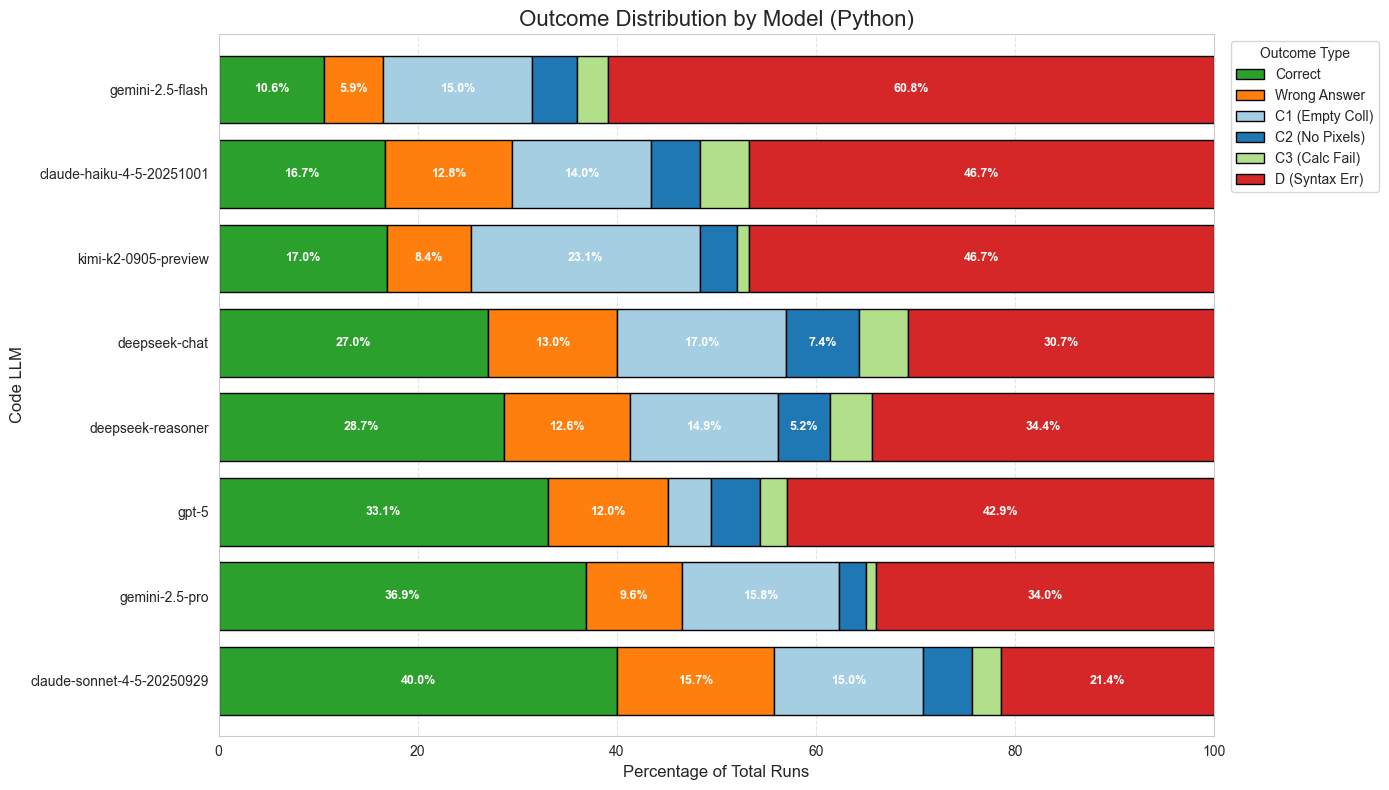

Stacked Bar Chart displayed.


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for Python
df_py = df[df['language'] == 'python'].copy()

# 2. define helper to categorize every single result
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    
    # Check for Correctness first
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'):
        return 'Correct'
    # Check for Valid but Wrong Answer (hallucination/logic error)
    elif pred in ['A', 'B']:
        return 'Wrong Answer'
    # Check for Technical Errors
    elif pred == 'C1': return 'C1 (Empty Coll)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    else: return 'Unknown'

df_py['outcome'] = df_py.apply(categorize_result, axis=1)

# 3. Create Pivot Table for Counts
pivot_counts = pd.crosstab(df_py['code_llm'], df_py['outcome'])

# Ensure all columns exist even if count is 0
desired_cols = ['Correct', 'Wrong Answer', 'C1 (Empty Coll)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']
for col in desired_cols:
    if col not in pivot_counts.columns:
        pivot_counts[col] = 0

# Reorder columns
pivot_counts = pivot_counts[desired_cols]

# 4. Calculate Percentages
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

# Add Total Samples for context
pivot_pct['Total Samples'] = pivot_counts.sum(axis=1)

# Sort by Accuracy (Correct)
pivot_pct = pivot_pct.sort_values(by='Correct', ascending=False)

# 5. Apply Styling
# We use different colormaps: Green for Good, Red/Orange for Bad
styled_breakdown = pivot_pct.style.format('{:.1f}%', subset=desired_cols)\
    .format('{:.0f}', subset=['Total Samples'])\
    .background_gradient(subset=['Correct'], cmap='Greens')\
    .background_gradient(subset=['Wrong Answer'], cmap='YlOrBr')\
    .background_gradient(subset=['D (Syntax Err)'], cmap='Reds')\
    .background_gradient(subset=['C1 (Empty Coll)', 'C2 (No Pixels)', 'C3 (Calc Fail)'], cmap='Oranges', axis=None)

print("Detailed Performance Breakdown by Error Type (Language: Python)")
display(styled_breakdown)

# 6. Visualization: Stacked Bar Chart
# This shows the composition of every model's output
ax = pivot_pct[desired_cols].plot(
    kind='barh', 
    stacked=True, 
    figsize=(14, 8),
    colormap='RdYlGn_r', # Red to Green reversed (so Correct is Green)
    edgecolor='black',
    linewidth=0.5
)

# Customizing the color map manually to ensure Correct is Green and D is Red
# (Optional: If the default colormap isn't distinct enough, we can map manually)
colors = {
    'Correct': '#2ca02c',       # Green
    'Wrong Answer': '#ff7f0e',  # Orange
    'C1 (Empty Coll)': '#a6cee3', # Light Blue
    'C2 (No Pixels)': '#1f78b4',  # Dark Blue
    'C3 (Calc Fail)': '#b2df8a',  # Light Green (or another neutral)
    'D (Syntax Err)': '#d62728'   # Red
}
# Re-plotting with specific colors
plt.clf() # clear previous
ax = pivot_pct[desired_cols].plot(
    kind='barh', 
    stacked=True, 
    figsize=(14, 8),
    color=[colors[x] for x in desired_cols],
    edgecolor='black',
    width=0.8
)

plt.title('Outcome Distribution by Model (Python)', fontsize=16)
plt.xlabel('Percentage of Total Runs', fontsize=12)
plt.ylabel('Code LLM', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Outcome Type')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels on the bars
for c in ax.containers:
    # Optional: Only label if segment is wide enough (>5%)
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.show()
print("Stacked Bar Chart displayed.")

Analyzing 3199 samples for Gemini 2.5 series...
Comparison: Python vs JavaScript (Gemini 2.5 Models)


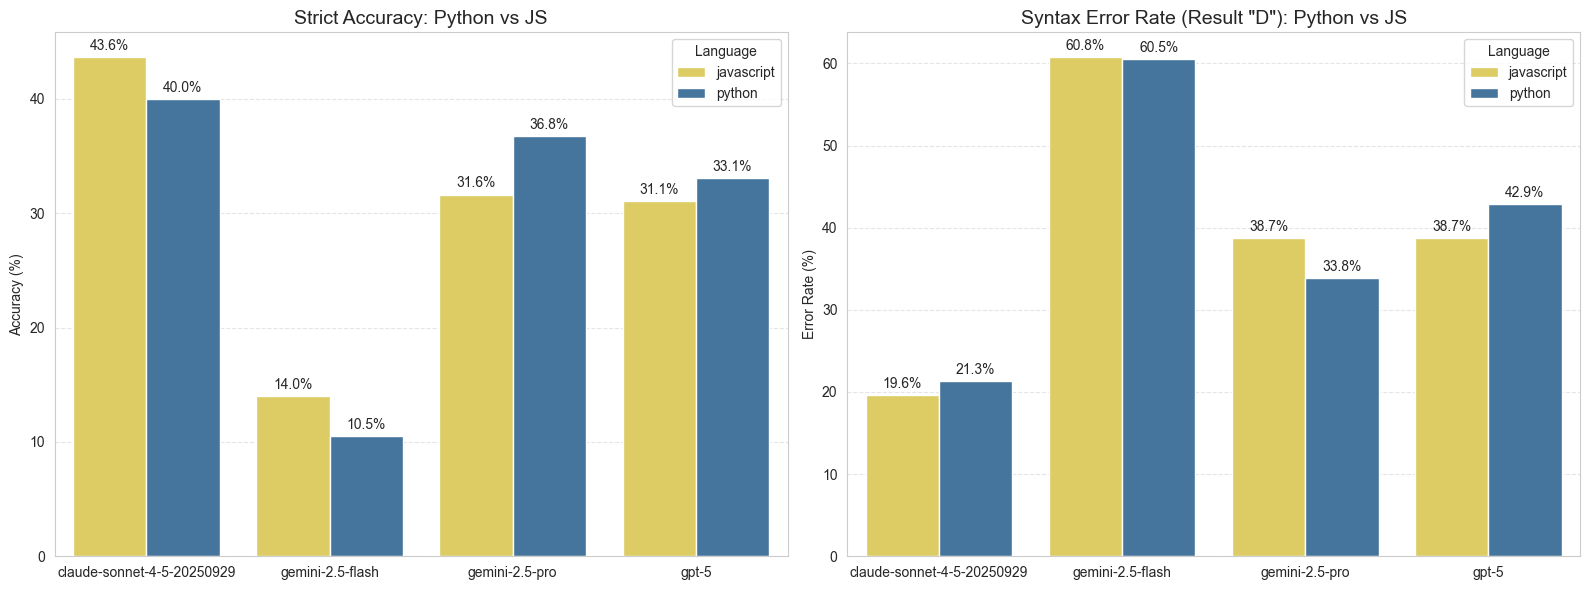

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/4006969921.py:151: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_df = df_target.groupby(['code_llm', 'language'])['outcome'].apply(lambda x: (x == 'Correct').mean() * 100).reset_index(name='Accuracy')
/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/4006969921.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)


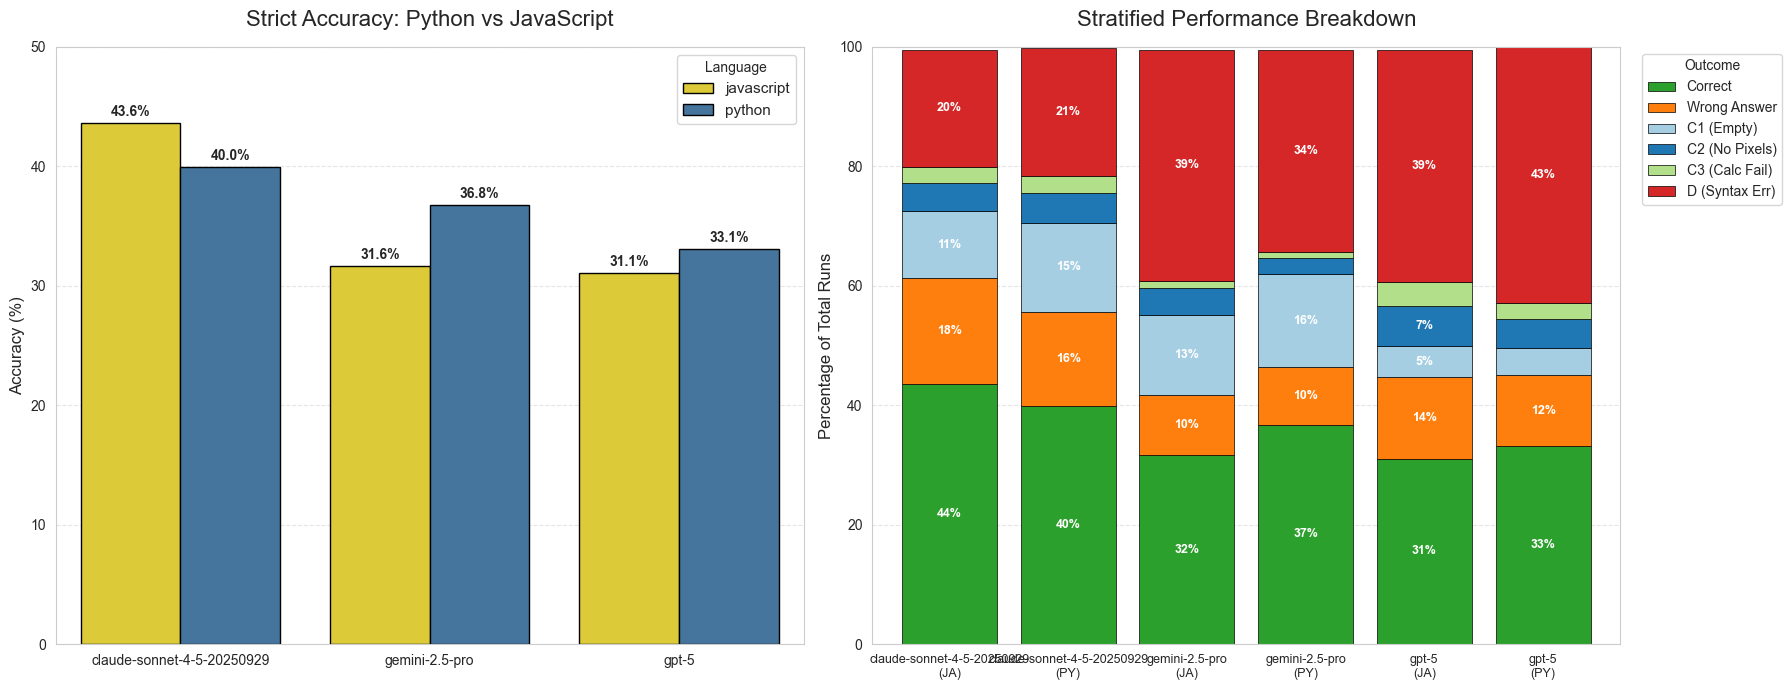

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter Data: Gemini 2.5 models only
# We look for "gemini-2.5" or "sonnet" in the code_llm name (case insensitive)
mask_model = df['code_llm'].str.contains('gemini-2.5|sonnet|gpt-5', case=False)
df_target = df[mask_model].copy()

print(f"Analyzing {len(df_target)} samples for Gemini 2.5 series...")

# 2. Reuse Categorization Logic
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'):
        return 'Correct'
    elif pred in ['A', 'B']:
        return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    else: return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# 3. Aggregate Data by Model AND Language
# Group by Model, Language, then Outcome
grouped = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)

# Calculate Percentages
# We divide by the sum of the row (total samples for that model+lang combo)
grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100

# 4. Create a Clean Summary Table
# We want to see Correct % and Syntax Error % side-by-side
summary = grouped_pct.copy()
summary['Total Samples'] = df_target.groupby(['code_llm', 'language']).size()

# Define columns to display (ensure they exist)
display_cols = ['Correct', 'D (Syntax Err)', 'C1 (Empty)', 'Wrong Answer', 'Total Samples']
for c in display_cols:
    if c not in summary.columns: summary[c] = 0.0

summary = summary[display_cols].sort_index()

# Style the table
styled_summary = summary.style.format({
    'Correct': '{:.1f}%',
    'D (Syntax Err)': '{:.1f}%',
    'C1 (Empty)': '{:.1f}%',
    'Wrong Answer': '{:.1f}%',
    'Total Samples': '{:.0f}'
}).background_gradient(subset=['Correct'], cmap='Greens')\
  .background_gradient(subset=['D (Syntax Err)'], cmap='Reds')

print("Comparison: Python vs JavaScript (Gemini 2.5 Models)")
display(styled_summary)

# --- VISUALIZATION ---

# Prepare data for plotting (melted format)
plot_data = grouped_pct.reset_index().melt(
    id_vars=['code_llm', 'language'], 
    value_vars=['Correct', 'D (Syntax Err)'],
    var_name='Metric', 
    value_name='Percentage'
)

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy Comparison
sns.barplot(
    data=plot_data[plot_data['Metric'] == 'Correct'],
    x='code_llm', 
    y='Percentage', 
    hue='language',
    palette={'python': '#3776ab', 'javascript': '#f0db4f'}, # Official logo colors approx
    ax=axes[0]
)
axes[0].set_title('Strict Accuracy: Python vs JS', fontsize=14)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='Language')

# Add values on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# Plot 2: Syntax Error Comparison
sns.barplot(
    data=plot_data[plot_data['Metric'] == 'D (Syntax Err)'],
    x='code_llm', 
    y='Percentage', 
    hue='language',
    palette={'python': '#3776ab', 'javascript': '#f0db4f'},
    ax=axes[1]
)
axes[1].set_title('Syntax Error Rate (Result "D"): Python vs JS', fontsize=14)
axes[1].set_ylabel('Error Rate (%)')
axes[1].set_xlabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Language')

# Add values on bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the exact order and models you want to compare
target_models = [
    'claude-sonnet-4-5-20250929', 
    'gemini-2.5-pro', 
    'gpt-5'
]

# Filter the dataframe for these models only
df_target = df[df['code_llm'].isin(target_models)].copy()

# Set categorical type to enforce sorting order in plots
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)

# 2. Categorize Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'):
        return 'Correct'
    elif pred in ['A', 'B']:
        return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    else: return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# 3. Prepare Data for Left Plot (Accuracy Only)
accuracy_df = df_target.groupby(['code_llm', 'language'])['outcome'].apply(lambda x: (x == 'Correct').mean() * 100).reset_index(name='Accuracy')

# 4. Prepare Data for Right Plot (Stratified/Stacked)
# Pivot: Index=(Model, Language), Columns=Outcome, Values=Count
stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)
# Convert to Percentage
stack_data_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

# Define specific column order for the stack (Correct at bottom, Errors on top)
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']
# Ensure all columns exist
for col in outcome_order:
    if col not in stack_data_pct.columns: stack_data_pct[col] = 0
stack_data_pct = stack_data_pct[outcome_order]

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ==========================
# LEFT PLOT: Strict Accuracy
# ==========================
sns.barplot(
    data=accuracy_df,
    x='code_llm',
    y='Accuracy',
    hue='language',
    palette={'python': '#3776ab', 'javascript': '#f7df1e'}, # Python Blue, JS Yellow
    ax=axes[0],
    edgecolor='black'
)

axes[0].set_title('Strict Accuracy: Python vs JavaScript', fontsize=16, pad=15)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='Language', fontsize=11)
axes[0].set_ylim(0, 50) # Adjust based on your max accuracy

# Add labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, weight='bold')

# ==========================================
# RIGHT PLOT: Stratified Performance Profile
# ==========================================
# Define colors for the stack segments
outcome_colors = {
    'Correct': '#2ca02c',       # Green
    'Wrong Answer': '#ff7f0e',  # Orange
    'C1 (Empty)': '#a6cee3',    # Light Blue
    'C2 (No Pixels)': '#1f78b4',# Dark Blue
    'C3 (Calc Fail)': '#b2df8a',# Light Green
    'D (Syntax Err)': '#d62728' # Red
}
color_list = [outcome_colors[col] for col in outcome_order]

# Plot stacked bar
# We flatten the index for x-labels: "Model\n(Lang)"
stack_plot_data = stack_data_pct.copy()
stack_plot_data.index = [f"{m}\n({l[:2].upper()})" for m, l in stack_plot_data.index]

stack_plot_data.plot(
    kind='bar',
    stacked=True,
    color=color_list,
    ax=axes[1],
    width=0.8,
    edgecolor='black',
    linewidth=0.5
)

axes[1].set_title('Stratified Performance Breakdown', fontsize=16, pad=15)
axes[1].set_ylabel('Percentage of Total Runs', fontsize=12)
axes[1].set_xlabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_ylim(0, 100)

# Clean up x-axis labels
plt.setp(axes[1].get_xticklabels(), rotation=0, fontsize=9)

# Add value labels (only if segment is big enough)
for c in axes[1].containers:
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 5 else '' for v in c]
    axes[1].bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.show()

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/594529896.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_df = df_target.groupby(['code_llm', 'language'])['outcome'].apply(lambda x: (x == 'Correct').mean() * 100).reset_index(name='Accuracy')
/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/594529896.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)
/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/594529896.py:82: UserWarning: set_ticklabels() should only

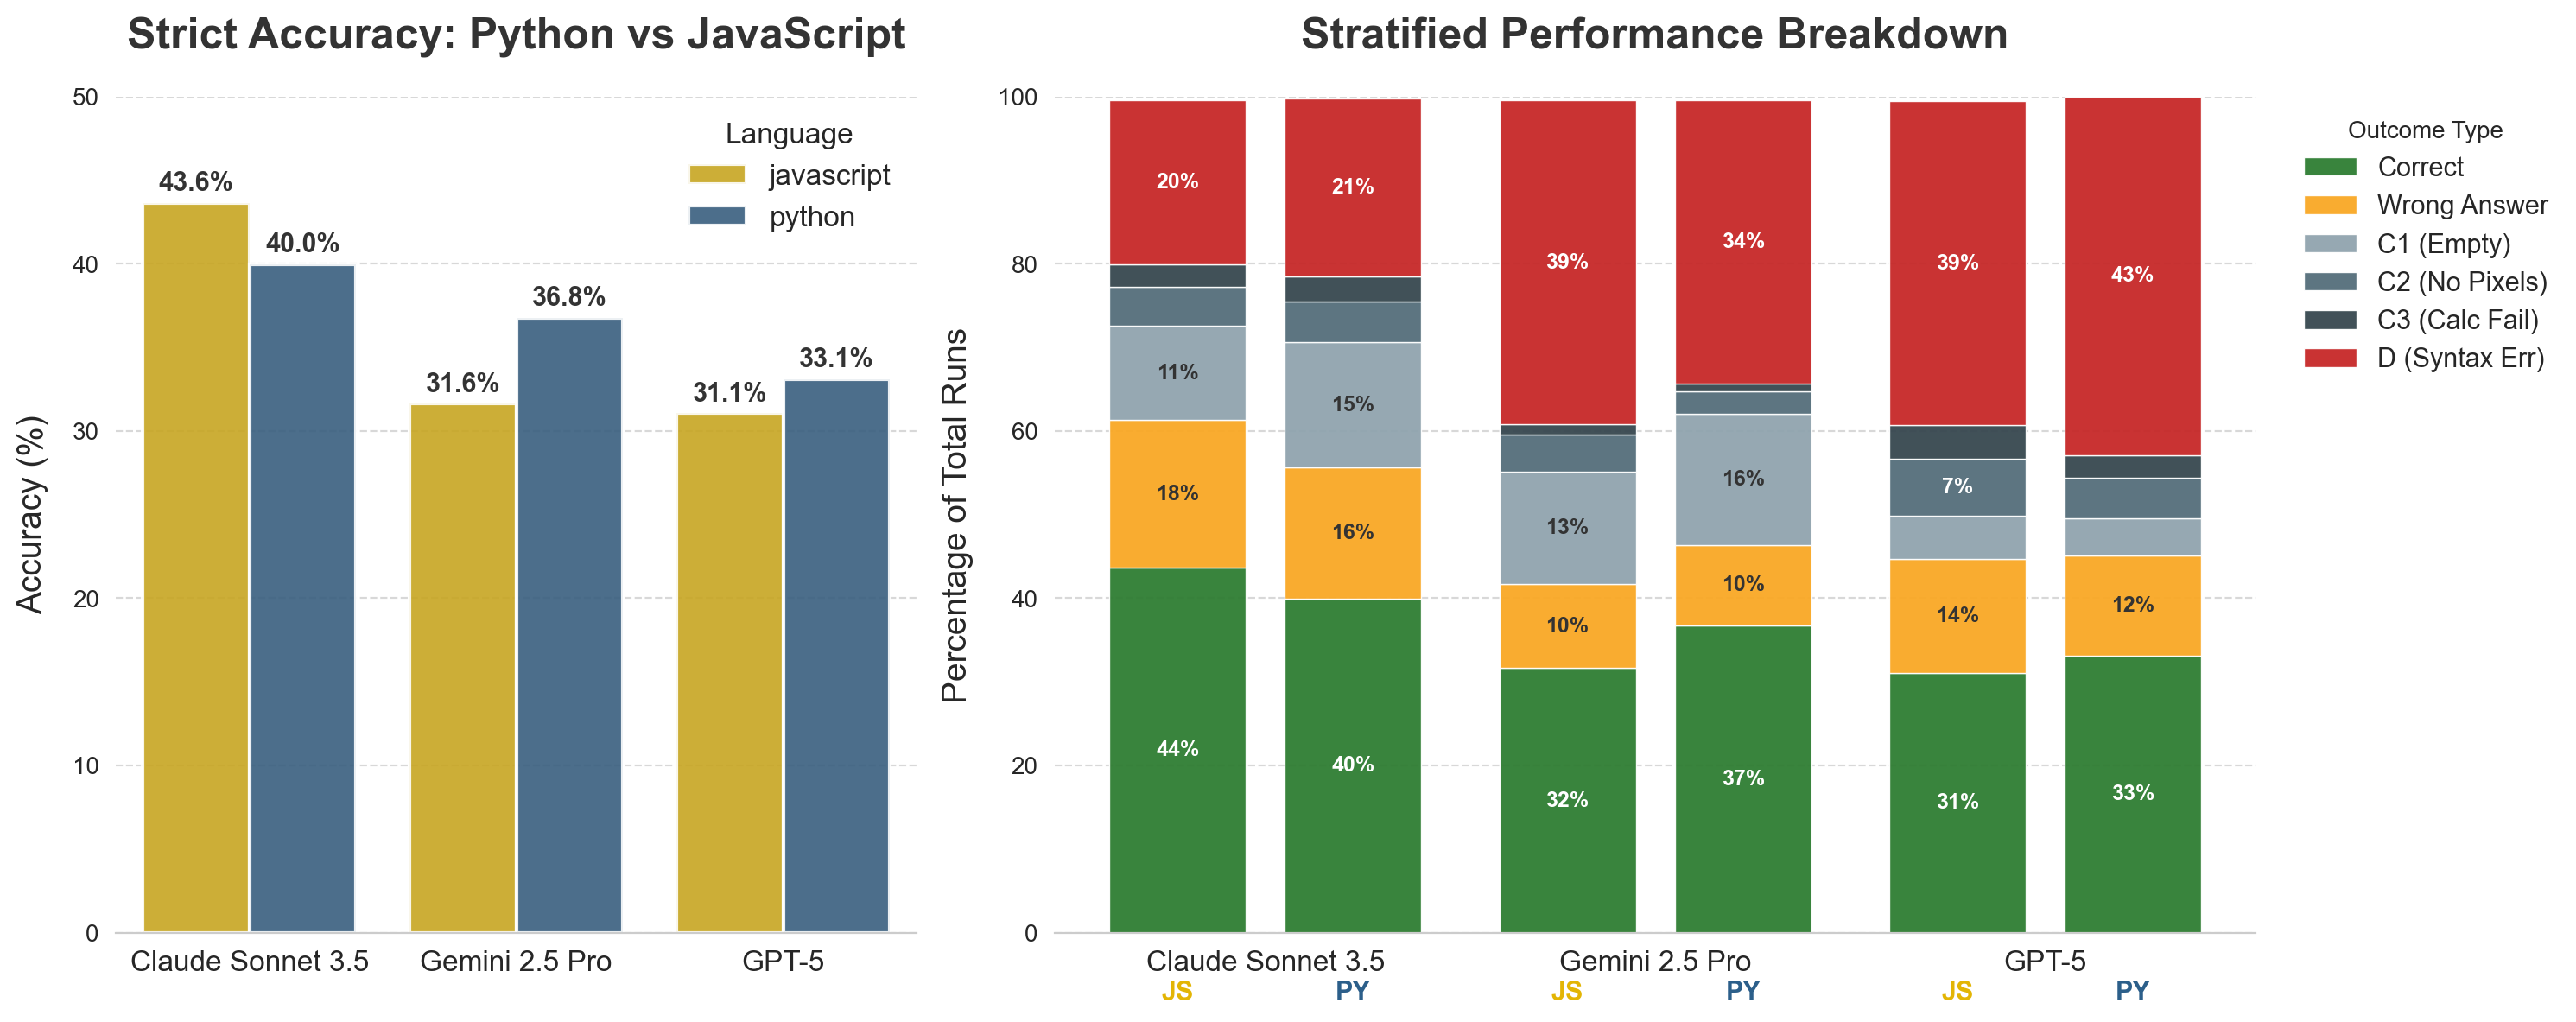

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION & DATA PREP ---

# Define Models and Order
target_models = ['claude-sonnet-4-5-20250929', 'gemini-2.5-pro', 'gpt-5']
model_labels = ['Claude Sonnet 3.5', 'Gemini 2.5 Pro', 'GPT-5'] # Pretty names for display

# Filter Data
df_target = df[df['code_llm'].isin(target_models)].copy()
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)

# Define Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'): return 'Correct'
    elif pred in ['A', 'B']: return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# --- 2. COLOR PALETTES (Professional Style) ---

# Left Plot: Language Comparison
# Python = Steel Blue, JS = Goldenrod (Readable Yellow)
lang_palette = {'python': '#2C5F8A', 'javascript': '#E3B505'} 

# Right Plot: Error Breakdown
# Green (Success) -> Orange (Logic Error) -> Greys/Blues (Execution Fail) -> Red (Syntax)
stack_colors = {
    'Correct':      '#2E7D32', # Forest Green
    'Wrong Answer': '#F9A825', # Muted Orange/Yellow
    'C1 (Empty)':   '#90A4AE', # Blue Grey
    'C2 (No Pixels)':'#546E7A', # Darker Blue Grey
    'C3 (Calc Fail)':'#37474F', # Slate
    'D (Syntax Err)':'#C62828'  # Deep Red
}
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']

# --- 3. DATA CALCULATION ---

# Left Plot Data (Accuracy)
acc_df = df_target.groupby(['code_llm', 'language'])['outcome'].apply(lambda x: (x == 'Correct').mean() * 100).reset_index(name='Accuracy')

# Right Plot Data (Stacked)
# Group by Model AND Language for the X-axis
stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100
for col in outcome_order:
    if col not in stack_pct.columns: stack_pct[col] = 0
stack_pct = stack_pct[outcome_order]

# --- 4. PLOTTING ---

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.5]}, dpi=200)
sns.set_style("whitegrid", {'axes.grid': False}) # We will add custom grids

# ==========================
# LEFT PLOT: Strict Accuracy
# ==========================
sns.barplot(
    data=acc_df, x='code_llm', y='Accuracy', hue='language',
    palette=lang_palette, ax=axes[0], 
    edgecolor='white', linewidth=1.5, alpha=0.9
)

# Styling Left
axes[0].set_title('Strict Accuracy: Python vs JavaScript', fontsize=18, pad=20, weight='bold', color='#333333')
axes[0].set_ylabel('Accuracy (%)', fontsize=14, labelpad=10)
axes[0].set_xlabel('')
axes[0].set_ylim(0, 50) # Set reasonable max
axes[0].grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)
axes[0].legend(title='Language', fontsize=12, title_fontsize=12, loc='upper right', frameon=False)
axes[0].set_xticklabels(model_labels, fontsize=12)

# Labels Left
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', padding=3, fontsize=11, weight='bold', color='#333333')

# ==========================================
# RIGHT PLOT: Grouped Stacked Bar (The "Hue" Effect)
# ==========================================
# To get the "Hue" effect in a stacked chart, we manually position bars.
# Positions: Sonnet(JS, Py) ...gap... Gemini(JS, Py) ...gap... GPT(JS, Py)

bar_width = 0.35
gap = 0.1
indices = np.arange(len(target_models))
# JS is left, Py is right
pos_js = indices - (bar_width / 2) - (gap / 2)
pos_py = indices + (bar_width / 2) + (gap / 2)

# Helper to plot a stack
def plot_stack_on_axis(ax, positions, language_key):
    # Filter data for this language
    subset = stack_pct.xs(language_key, level='language')
    bottoms = np.zeros(len(subset))
    
    for outcome in outcome_order:
        values = subset[outcome].values
        ax.bar(
            positions, values, bottom=bottoms, width=bar_width, 
            label=outcome if language_key == 'python' else "", # Only label once for legend
            color=stack_colors[outcome], edgecolor='white', linewidth=0.5, alpha=0.95
        )
        # Add labels inside bars if segment is large enough (>5%)
        for i, val in enumerate(values):
            if val > 6:
                y_center = bottoms[i] + (val / 2)
                # White text for dark bars, Black for light bars
                text_color = 'white' if outcome in ['Correct', 'D (Syntax Err)', 'C2 (No Pixels)', 'C3 (Calc Fail)'] else '#333333'
                ax.text(positions[i], y_center, f"{val:.0f}%", ha='center', va='center', 
                        color=text_color, fontsize=9, weight='bold')
        bottoms += values

# Plot JS bars (Left of center)
plot_stack_on_axis(axes[1], pos_js, 'javascript')
# Plot Python bars (Right of center)
plot_stack_on_axis(axes[1], pos_py, 'python')

# Styling Right
axes[1].set_title('Stratified Performance Breakdown', fontsize=18, pad=20, weight='bold', color='#333333')
axes[1].set_ylabel('Percentage of Total Runs', fontsize=14, labelpad=10)
axes[1].set_xticks(indices)
axes[1].set_xticklabels(model_labels, fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)

# Custom X-Axis Annotations to show Language below Model
y_min = -8 # Position below axis
for i in indices:
    axes[1].text(pos_js[i], y_min, "JS", ha='center', fontsize=11, color=lang_palette['javascript'], weight='bold')
    axes[1].text(pos_py[i], y_min, "PY", ha='center', fontsize=11, color=lang_palette['python'], weight='bold')

# Legend (Reconstruct handles to ensure correct order and unique entries)
handles, labels = axes[1].get_legend_handles_labels()
# Filter unique labels (preserving order)
by_label = dict(zip(labels, handles))
# Sort by our outcome_order reversed (so Syntax is top of legend, Correct is bottom) or kept as is
axes[1].legend(
    [by_label[k] for k in outcome_order], 
    outcome_order, 
    title='Outcome Type', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=False,
    fontsize=11
)

sns.despine(left=True) # Remove left/top/right box lines
plt.tight_layout()
# plt.show()
plt.savefig('./figures/python_js_comparison.pdf', dpi=300, bbox_inches='tight')

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_98399/1445109252.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)


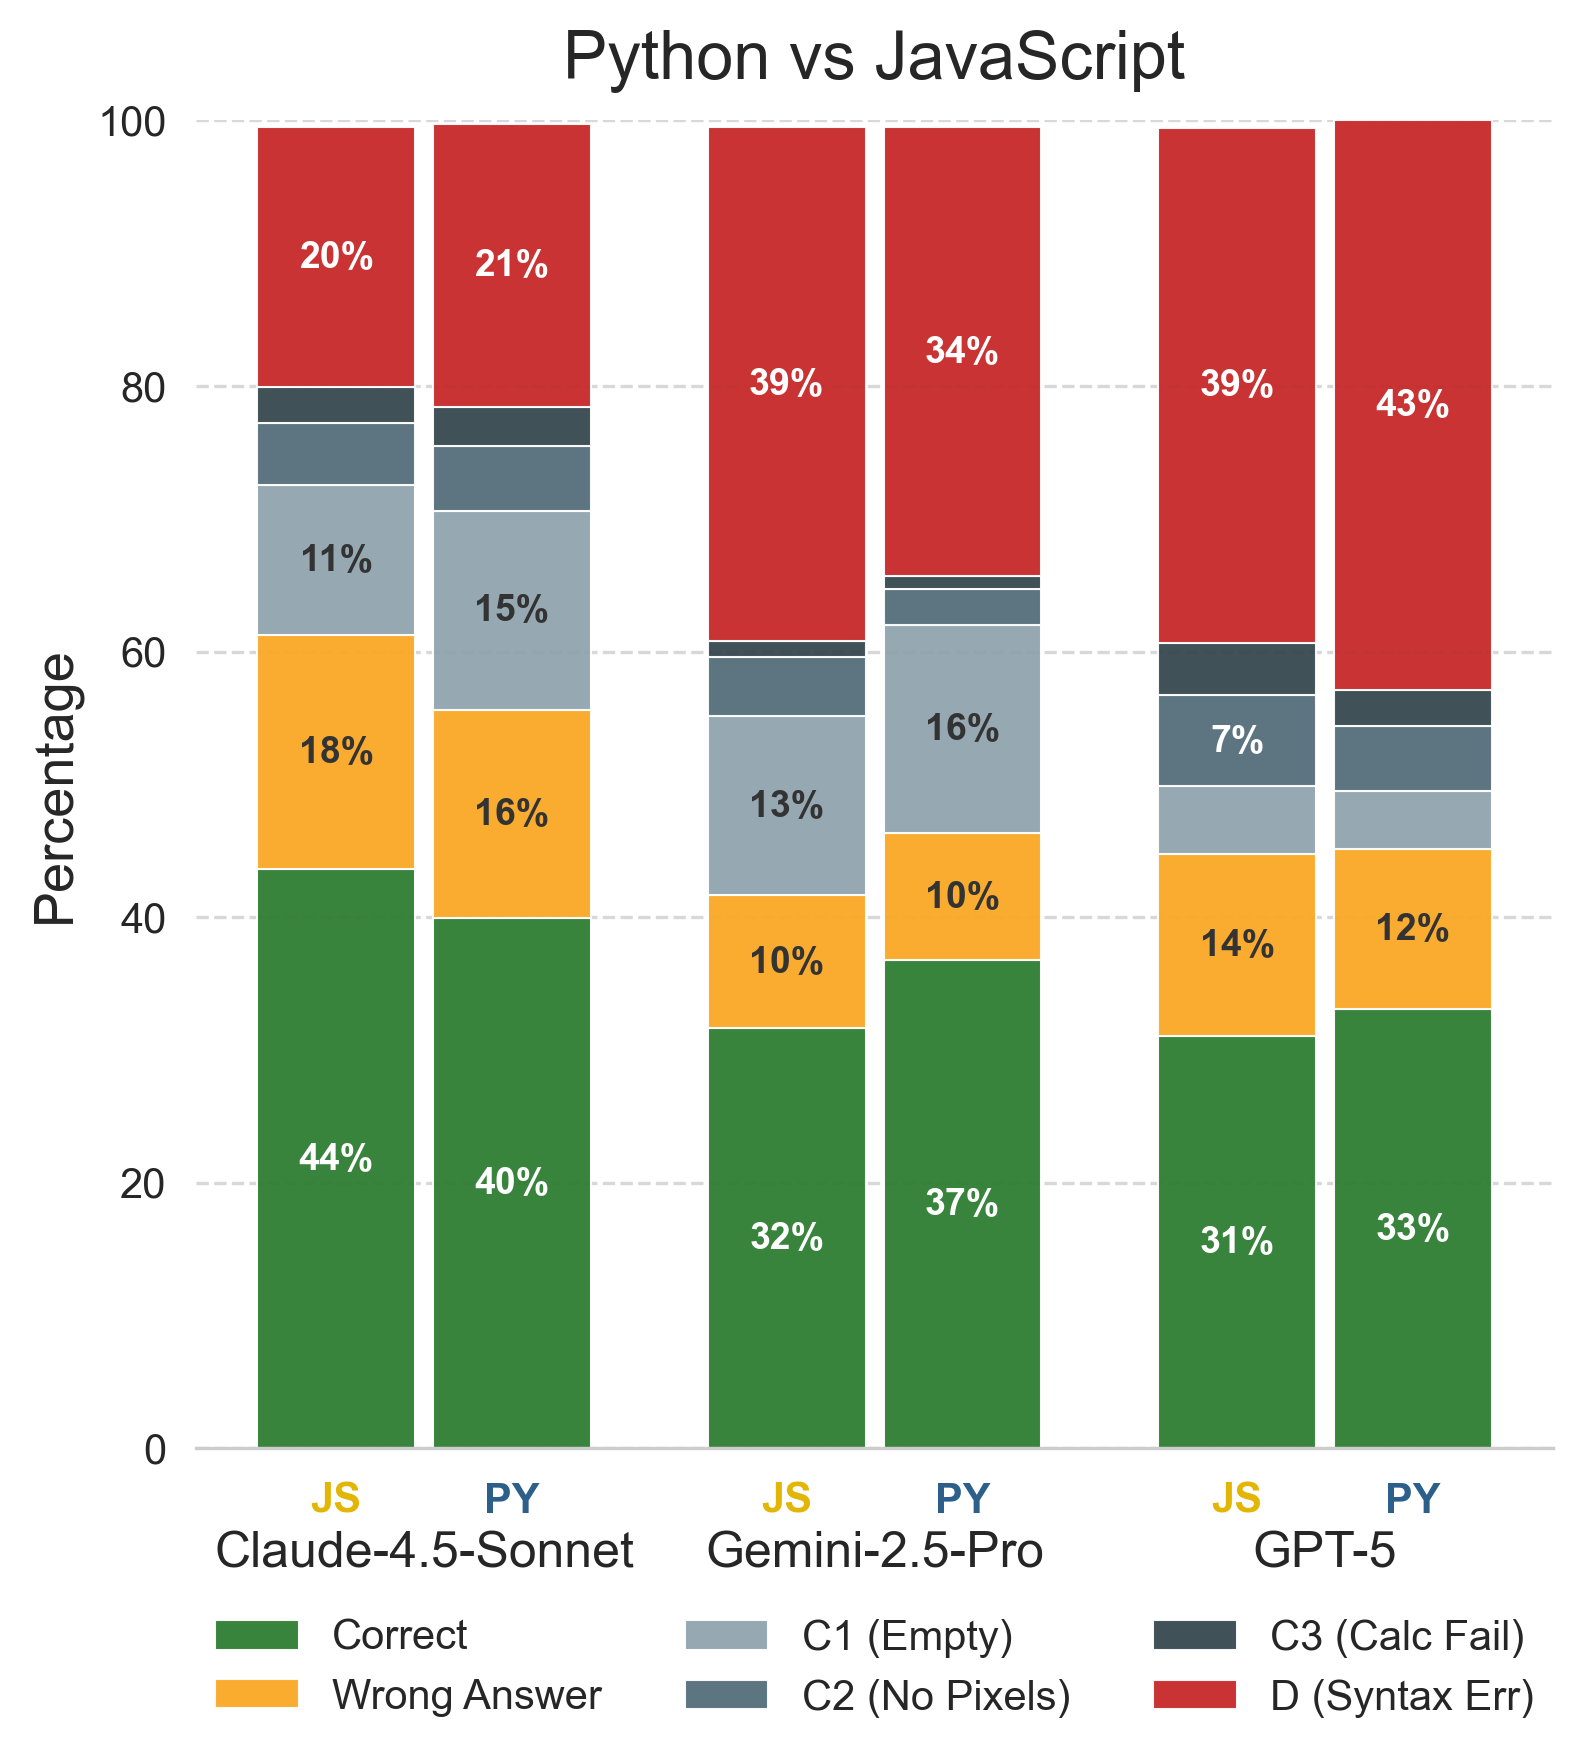

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION & DATA PREP ---

# NOTE: Assumes 'df' is already loaded with columns: 'code_llm', 'gt_answer', 'pred_code', 'language'

# Define Models and Order
target_models = ['claude-sonnet-4-5-20250929', 'gemini-2.5-pro', 'gpt-5']
model_labels = ['Claude-4.5-Sonnet', 'Gemini-2.5-Pro', 'GPT-5']

# Filter Data
df_target = df[df['code_llm'].isin(target_models)].copy()
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)

# Define Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'): return 'Correct'
    elif pred in ['A', 'B']: return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# --- 2. COLOR PALETTES ---

# Text Colors for JS/PY labels
lang_colors = {'python': '#2C5F8A', 'javascript': '#E3B505'} 

# Outcome Colors
stack_colors = {
    'Correct':      '#2E7D32', # Forest Green
    'Wrong Answer': '#F9A825', # Muted Orange/Yellow
    'C1 (Empty)':   '#90A4AE', # Blue Grey
    'C2 (No Pixels)':'#546E7A', # Darker Blue Grey
    'C3 (Calc Fail)':'#37474F', # Slate
    'D (Syntax Err)':'#C62828'  # Deep Red
}
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']

# --- 3. DATA CALCULATION ---

# Group by Model AND Language
stack_data = df_target.groupby(['code_llm', 'language', 'outcome']).size().unstack(fill_value=0)

# Calculate Percentages
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

# Ensure all columns exist
for col in outcome_order:
    if col not in stack_pct.columns: 
        stack_pct[col] = 0
        
# Reorder columns
stack_pct = stack_pct[outcome_order]

# --- 4. PLOTTING ---

# Create single figure
fig, ax = plt.subplots(figsize=(5.5, 6), dpi=300)
sns.set_style("whitegrid", {'axes.grid': False})

# Bar Layout Definitions
bar_width = 0.35
gap = 0.04 # Space between JS and PY bars for the same model
indices = np.arange(len(target_models))

# Calculate X positions
pos_js = indices - (bar_width / 2) - (gap / 2)
pos_py = indices + (bar_width / 2) + (gap / 2)

# Helper function to plot a stack
def plot_stack(axis, positions, language_key):
    # Get data for specific language
    try:
        subset = stack_pct.xs(language_key, level='language')
    except KeyError:
        return # Handle case where a language might be missing entirely
        
    bottoms = np.zeros(len(subset))
    
    for outcome in outcome_order:
        values = subset[outcome].values
        axis.bar(
            positions, values, bottom=bottoms, width=bar_width, 
            label=outcome, # Label applied here, filtered later for legend
            color=stack_colors[outcome], edgecolor='white', linewidth=0.5, alpha=0.95
        )
        
        # Add Percentage Labels inside bars
        for i, val in enumerate(values):
            if val > 6: # Only label if segment is large enough
                y_center = bottoms[i] + (val / 2)
                # White text for dark bars, Dark text for light bars
                text_color = 'white' if outcome in ['Correct', 'D (Syntax Err)', 'C2 (No Pixels)', 'C3 (Calc Fail)'] else '#333333'
                axis.text(positions[i], y_center, f"{val:.0f}%", ha='center', va='center', 
                        color=text_color, fontsize=9, weight='bold')
        
        bottoms += values

# Plot JS (Left) and Python (Right)
plot_stack(ax, pos_js, 'javascript')
plot_stack(ax, pos_py, 'python')

# --- 5. STYLING & LABELS ---

ax.set_title('Python vs JavaScript', fontsize=16, pad=10)
ax.set_ylabel('Percentage', fontsize=13)
ax.set_xlabel('')

# X-Axis Settings
ax.set_xticks(indices)
ax.set_xticklabels(model_labels, fontsize=12, weight='medium')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)

# KEY CHANGE 1: Push the standard X-axis labels (Model Names) down 
# 'pad=25' adds space between the axis line and the Model Name text
ax.tick_params(axis='x', which='major', pad=20, length=0) 

# KEY CHANGE 2: Place JS/PY labels in the gap created above
# We set y to a small negative number (relative to 0-100 scale) to sit right under the bar
y_label_js_py = -4

for i in indices:
    # JS Label
    ax.text(pos_js[i], y_label_js_py, "JS", ha='center', va='center', 
            fontsize=10, color=lang_colors['javascript'], weight='bold')
    # PY Label
    ax.text(pos_py[i], y_label_js_py, "PY", ha='center', va='center', 
            fontsize=10, color=lang_colors['python'], weight='bold')

# Legend Logic
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles)) # Deduplicate handles

# Position legend outside to the right
ax.legend(
    [by_label[k] for k in outcome_order], 
    outcome_order, 
    title='', # Usually cleaner without title when horizontal
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.1), # (X=Center, Y=Below Axis). Adjust -0.2 if it overlaps text.
    ncol=3, # 3 Columns (2 rows). Change to 6 for a single flat row if width permits.
    frameon=False,
    fontsize=10
)

sns.despine(left=True) # Clean borders
plt.tight_layout()

# Save
plt.savefig('./figures/python_js_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
https://docs.google.com/spreadsheets/d/1Nqhjav4AJZFY8_0zH0X71TBp3q9q2RMvQcHymMupT8k/edit?usp=sharing

SyntaxError: invalid decimal literal (4250958575.py, line 1)